In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

In [3]:
df.head()   

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [4]:
df.shape

(37249, 2)

In [5]:
df['clean_comment'].sample().values

<StringArray>
['and one gives thought those poor farmers who died from hunger when mayawati spent all that money her own statues praising such double standards might help you sleep night but won change reality ']
Length: 1, dtype: str

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   clean_comment  37149 non-null  str  
 1   category       37249 non-null  int64
dtypes: int64(1), str(1)
memory usage: 582.1 KB


In [7]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [8]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [9]:
df[df['clean_comment'].isna()]['category'].value_counts()

category
0    100
Name: count, dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(350)

In [12]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[(df['clean_comment'].str.strip() == '') & (df['category'] == 'neutral')]

,clean_comment,category


In [16]:
df=df[~((df['clean_comment'].str.strip() == '') & (df['category'] == 'neutral'))]

In [17]:
df['clean_comment']=df['clean_comment'].str.lower()

In [18]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [19]:
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [20]:
df['clean_comment'] = df['clean_comment'].str.strip()

In [21]:
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category


In [22]:
comments_with_newlines = df[df['clean_comment'].str.contains('\n')]

comments_with_newlines.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [23]:
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=True)

In [24]:
comments_with_newline_remaining = df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category


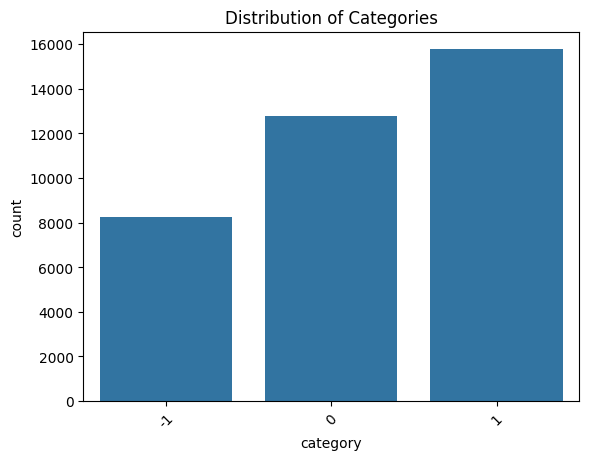

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='category', data=df)
plt.title('Distribution of Categories')
plt.xticks(rotation=45)
plt.show()

In [26]:
df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.72
-1    22.42
Name: proportion, dtype: float64

In [27]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))

In [28]:
df.sample(5)

,clean_comment,category,word_count
25140,the data for number official trips was taken f...,0,20
7494,fuck them all thats his right free speech and ...,1,15
11352,tbqh they are brahmin because you are brahmin ...,0,79
25699,what are these rounds seat counted eli5 please,0,8
16544,what would give for that hairstyle game,-1,7


In [29]:
df['word_count'].describe()

count    36799.000000
mean        29.662627
std         56.787371
min          0.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

Text(0.5, 1.0, 'Distribution of Word Counts')

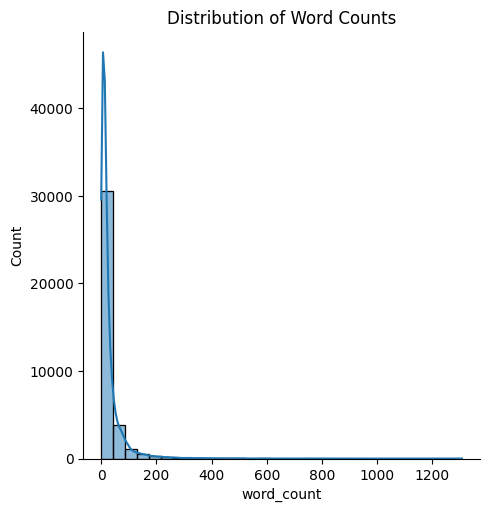

In [30]:
sns.displot(df['word_count'], bins=30, kde=True)
plt.title('Distribution of Word Counts')

C:\Users\adity\AppData\Local\Temp\ipykernel_393556\585977119.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', shade=True)
C:\Users\adity\AppData\Local\Temp\ipykernel_393556\585977119.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', shade=True)
C:\Users\adity\AppData\Local\Temp\ipykernel_393556\585977119.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', shade=True)


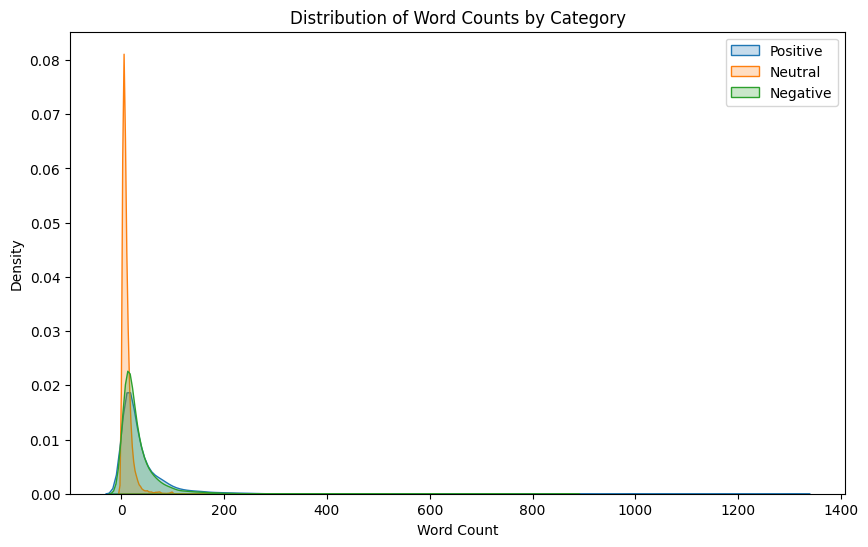

In [32]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', shade=True)

sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', shade=True)

sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', shade=True)
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.title('Distribution of Word Counts by Category')
plt.legend()

<Axes: ylabel='word_count'>

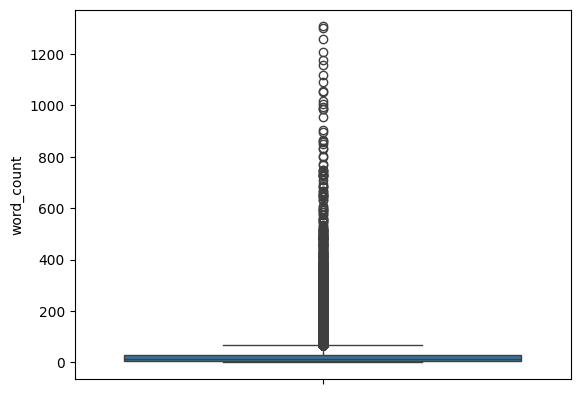

In [33]:
sns.boxplot(df['word_count'])

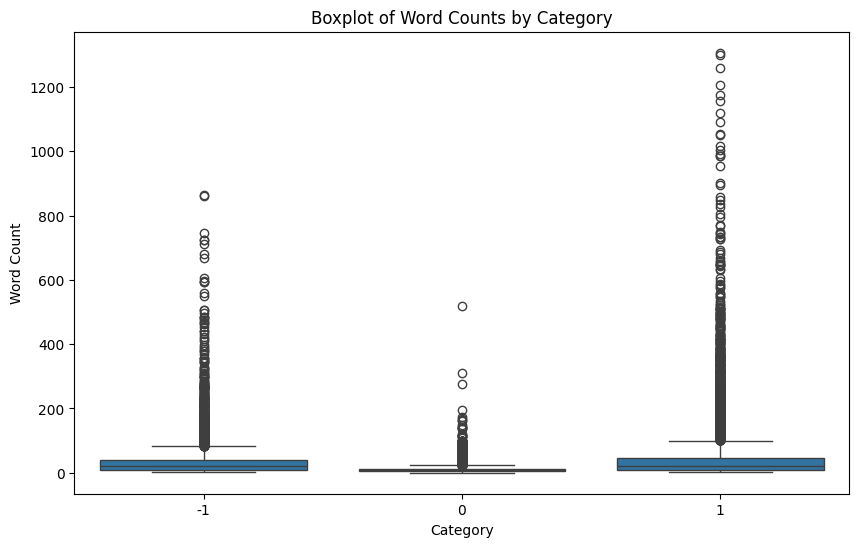

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='word_count', data=df)
plt.title('Boxplot of Word Counts by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

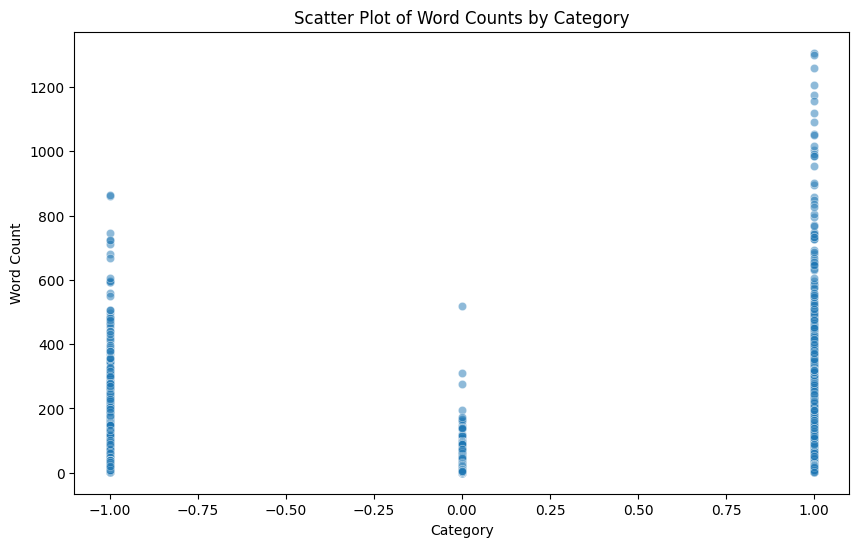

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='category', y='word_count', data=df, alpha=0.5)
plt.title('Scatter Plot of Word Counts by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

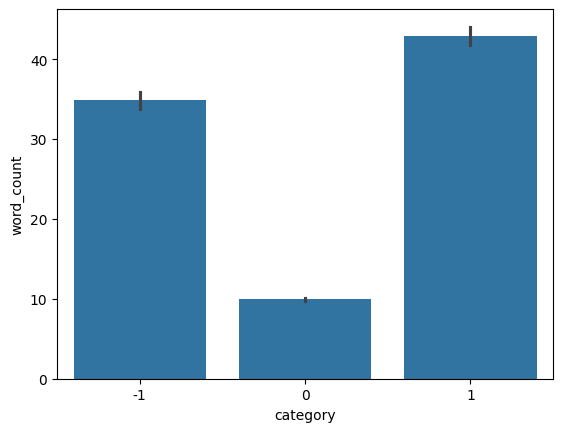

In [38]:
sns.barplot(x='category', y='word_count', estimator='mean', data=df)

In [39]:
!pip install nltk


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
from nltk.corpus import stopwords

import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adity\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [41]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
3094,both congress and might get seats maharashtra,0,7,2
11348,wasn this the same director and was good well,1,9,6
22105,satish acharya latest jpg,1,4,0
18621,more anonymous unverifiable allegations,1,4,1
22342,woooo,0,1,0


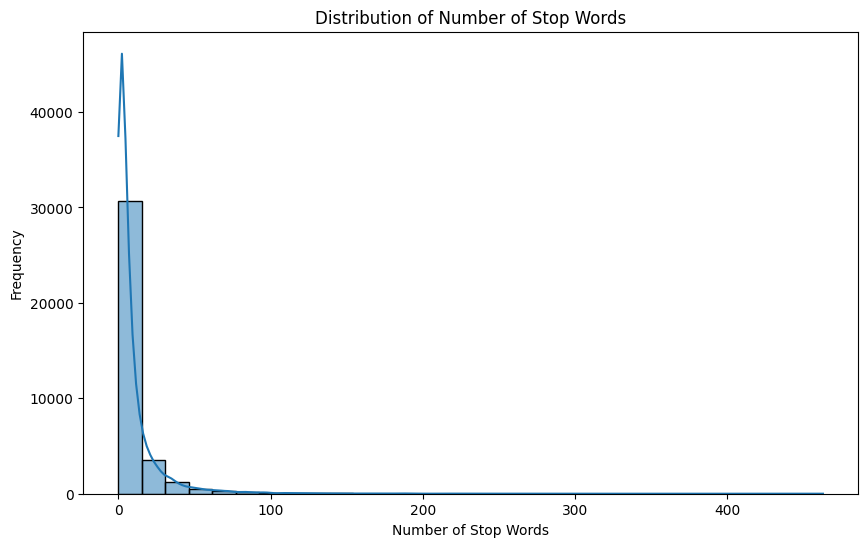

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], bins=30, kde=True)
plt.title('Distribution of Number of Stop Words')  
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

C:\Users\adity\AppData\Local\Temp\ipykernel_393556\61330229.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', shade=True)
C:\Users\adity\AppData\Local\Temp\ipykernel_393556\61330229.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', shade=True)
C:\Users\adity\AppData\Local\Temp\ipykernel_393556\61330229.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', shade=True)


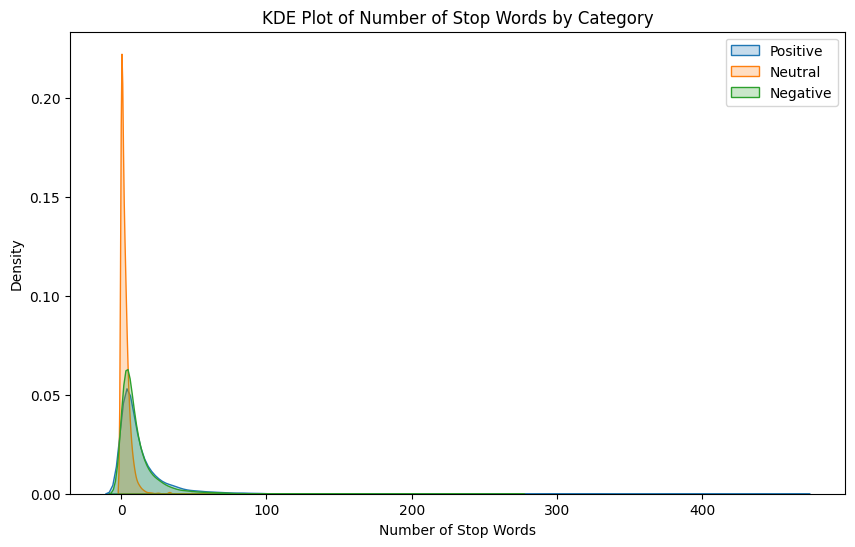

In [43]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', shade=True)
sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', shade=True)
sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', shade=True)
plt.xlabel('Number of Stop Words')
plt.ylabel('Density')
plt.title('KDE Plot of Number of Stop Words by Category')
plt.legend()
plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

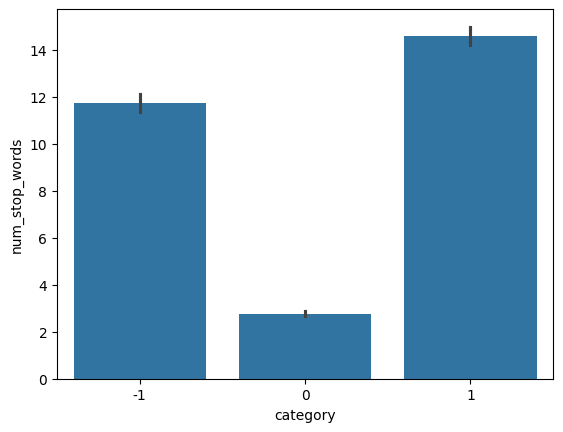

In [44]:
sns.barplot(x='category', y='num_stop_words', estimator='mean', data=df)

C:\Users\adity\AppData\Local\Temp\ipykernel_393556\2119357454.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='stop_word', data=top_25_df, palette='viridis')


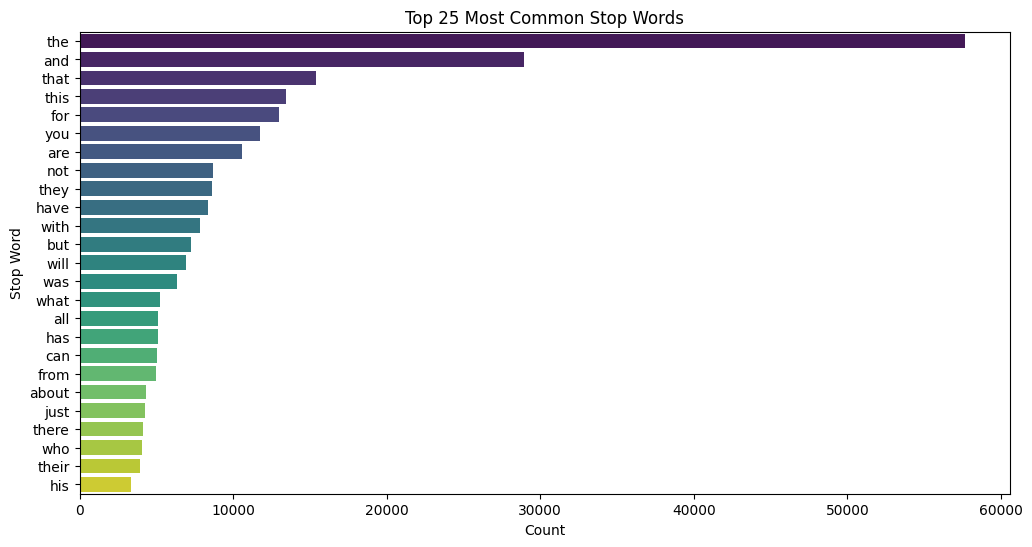

In [45]:
from collections import Counter

all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]


most_common_stop_words = Counter(all_stop_words).most_common(25)

top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='stop_word', data=top_25_df, palette='viridis')
plt.title('Top 25 Most Common Stop Words')  
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()

In [46]:
df['num_chars'] =  df['clean_comment'].apply(len)

df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [47]:
df['num_chars'].describe()

count    36799.000000
mean       181.823147
std        359.680331
min          0.000000
25%         38.000000
50%         80.000000
75%        184.000000
max       8664.000000
Name: num_chars, dtype: float64

In [55]:
from collections import Counter

all_text = ' '.join(df['clean_comment'])

char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

In [56]:
char_frequency_df['character'].values

<StringArray>
[' ', 'e', 't', 'a', 'i', 'n', 'o', 's', 'r', 'h',
 ...
 '遥', '则', '豹', '皿', '煮', '唯', '统', '段', '她', '谁']
Length: 1378, dtype: str

In [57]:
char_frequency_df.tail(50)

,character,frequency
1286,货,1
1287,语,1
1312,耐,1
1313,精,1
342,━,1
345,⊂,1
346,゜,1
347,ｊ,1
1289,显,1
1291,鞋,1


In [58]:
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
2214,why according all places should retain their n...,0,13,7,82,0
11986,add simblified,0,2,0,14,0
3451,malayalee guessing the nayars mentioned the ar...,-1,92,40,542,0
14173,that bro hug,0,3,1,12,0
17981,well played dhoni and thank you for saving our...,0,10,4,51,0


In [59]:
df['num_punctuation_chars'].describe()

count    36799.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_punctuation_chars, dtype: float64

C:\Users\adity\AppData\Local\Temp\ipykernel_393556\3992001145.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


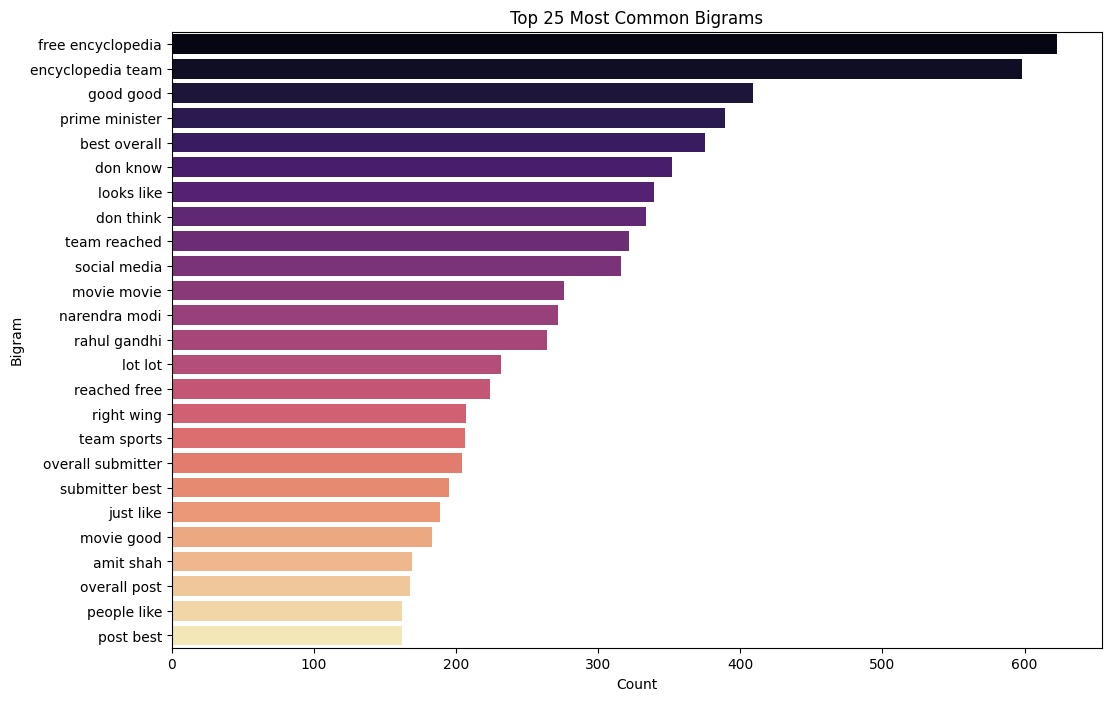

In [60]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)


top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


C:\Users\adity\AppData\Local\Temp\ipykernel_393556\952138944.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')


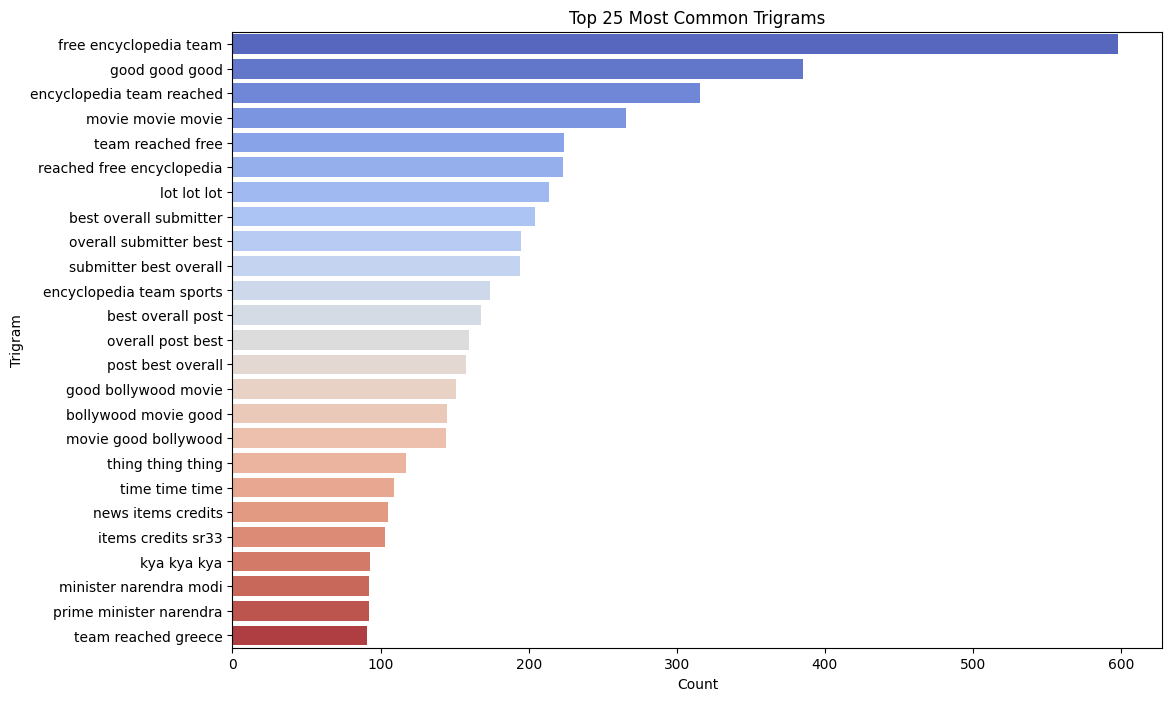

In [61]:
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]


top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)


top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [62]:
import re

df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

In [63]:
all_text = ' '.join(df['clean_comment'])

char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

char_frequency_df

,character,frequency
6,,1091598
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [64]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0
